# Modelado 2D — Predicción de `Unit Price (USD)` con dataset reducido

**Pregunta de negocio**: ¿podemos lograr resultados comparables al modelo `02_modeling.ipynb` (22 features, requiere CAD) usando sólo las **12 features llenables desde un plano 2D**?

Si la caída de desempeño es pequeña, la decisión es ganadora: ampliamos el dataset incluyendo todos los pedidos históricos (no sólo los con CAD analizado), lo que probablemente sea la palanca más grande para mejorar el modelo en el futuro.

**Setup idéntico al notebook 02** para hacer la comparación limpia:
- Mismo `SEED = 42` → mismo train/test split (mismas filas).
- Misma configuración de CatBoost cuantil α=0.8.
- Mismo helper `error_summary`, mismas métricas.

**Única diferencia**: features.
- v1 (notebook 02): 22 features incluyendo geometría CAD detallada.
- v2 (este notebook): 12 features llenables manualmente desde 2D + título block + PO.

**Sobre `Heat Treatment` y `Post Production`**: NaN en estas columnas significa **"no se aplica"** (no es dato faltante). Por eso usamos la etiqueta `'None'` (no `'Missing'`) al imputar — refleja semánticamente que es una categoría legítima ("la pieza no requiere tratamiento térmico" / "no requiere post-producción").

**Pipeline**:
1. Cargar `line_items_2d.parquet`.
2. Definir features (12) + target.
3. Helpers de métricas.
4. Train/test split estratificado.
5. Baselines triviales.
6. Modelo principal con 5-fold CV.
7. Modelo final + evaluación en test + diagnóstico.
8. Feature importance + SHAP.
9. **Comparativa v1 vs v2** ← veredicto.
10. Persistencia.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedKFold

from catboost import CatBoostRegressor, Pool
import shap

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

SEED = 42
TEST_SIZE = 0.20
ALPHA = 0.80

DATA_PATH   = Path('line_items_2d.parquet')
MODEL_PATH  = Path('catboost_model_2d.cbm')
SCHEMA_PATH = Path('catboost_schema_2d.json')

C:\Users\Imanol\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cargar dataset 2D

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nDtypes:')
print(df.dtypes.to_string())
df.head(3)

Shape: (386, 14)

Dtypes:
Material                 category
Technology               category
Tolerance                 float64
Post Production          category
Finishing                category
Heat Treatment           category
Quantity                    int64
Unit Price (USD)          float64
stock_dimensions_mm.x     float64
stock_dimensions_mm.y     float64
stock_dimensions_mm.z     float64
total_holes               float64
part_type                category
log_unit_price            float64


,Material,Technology,Tolerance,Post Production,Finishing,Heat Treatment,Quantity,Unit Price (USD),stock_dimensions_mm.x,stock_dimensions_mm.y,stock_dimensions_mm.z,total_holes,part_type,log_unit_price
0,Other_rare,CNC Multiaxis,0.050,Anodizing II,As Machined,NaN,10,58.0000,57.1,12.7,101.6,8.0,rotational,4.060443
1,6061-T6 Aluminum,CNC Multiaxis,0.025,Other_rare,As Machined,NaN,10,174.0000,88.9,12.7,108.0,8.0,rotational,5.159055
2,Other,3D Printing SLS,0.127,NaN,Smooth Machining,NaN,1,103.5108,101.6,304.8,12.7,0.0,complex_3d,4.639676


## 2. Features, target y categóricas

Features (12): `Material`, `Technology`, `Tolerance`, `Finishing`, `Heat Treatment`, `Post Production`, `Quantity`, `stock_dimensions_mm.x/y/z`, `total_holes`, `part_type`.  
Targets: `Unit Price (USD)` (USD original) y `log_unit_price` (modelo).

**Categóricas (6)**: las 4 originales (`Material`, `Technology`, `Finishing`, `part_type`) más `Heat Treatment` y `Post Production`.

**Imputación de NaN en categóricas**:
- `Heat Treatment` y `Post Production`: NaN → `'None'` (semánticamente "no se aplica tratamiento" — categoría real con señal).
- Otras categóricas: NaN → `'Missing'` (genuinamente no capturado).

In [3]:
TARGET = 'log_unit_price'
TARGET_USD = 'Unit Price (USD)'

cat_features = ['Material', 'Technology', 'Finishing', 'part_type', 'Heat Treatment', 'Post Production']

# NaN en Heat Treatment / Post Production no es dato faltante — significa "no se aplica".
no_treatment_cols = {'Heat Treatment', 'Post Production'}

feature_cols = [c for c in df.columns if c not in {TARGET, TARGET_USD}]

X     = df[feature_cols].copy()
y     = df[TARGET]
y_usd = df[TARGET_USD]

# fillna ANTES de astype(str) para que NaN se reemplace correctamente
# (astype(str) sobre NaN produce el literal 'nan', perdiendo la oportunidad).
for c in cat_features:
    fill_value = 'None' if c in no_treatment_cols else 'Missing'
    X[c] = X[c].astype('object').where(X[c].notna(), fill_value).astype(str)

print(f'Features ({len(feature_cols)}):')
for c in feature_cols:
    print(f'  - {c}  ({X[c].dtype})')

print(f'\nValores únicos tras imputación:')
for c in ['Heat Treatment', 'Post Production']:
    vals = sorted(X[c].unique().tolist())
    print(f'  {c}: {vals}')

Features (12):
  - Material  (object)
  - Technology  (object)
  - Tolerance  (float64)
  - Post Production  (object)
  - Finishing  (object)
  - Heat Treatment  (object)
  - Quantity  (int64)
  - stock_dimensions_mm.x  (float64)
  - stock_dimensions_mm.y  (float64)
  - stock_dimensions_mm.z  (float64)
  - total_holes  (float64)
  - part_type  (object)

Valores únicos tras imputación:
  Heat Treatment: ['None', 'Other', 'Other_rare', 'Quenching', 'Tempering']
  Post Production: ['Anodizing II', 'Black Oxide Coating', 'Laser Engraving', 'None', 'Other', 'Other_rare']


## 3. Helpers de métricas

Idéntico al notebook 02.

In [4]:
def error_summary(y_log_true, y_log_pred, label='Model', alpha=None):
    y_log_true = np.asarray(y_log_true)
    y_log_pred = np.asarray(y_log_pred)

    y_true_usd = np.exp(y_log_true)
    y_pred_usd = np.exp(y_log_pred)

    mae_log  = mean_absolute_error(y_log_true, y_log_pred)
    rmse_log = np.sqrt(mean_squared_error(y_log_true, y_log_pred))
    err_pct  = np.abs(y_pred_usd - y_true_usd) / y_true_usd * 100
    mape_usd = err_pct.mean()

    underpred_mask = y_pred_usd < y_true_usd
    overpred_mask  = y_pred_usd > y_true_usd
    underpred_pct  = underpred_mask.mean() * 100

    avg_under = ((y_true_usd - y_pred_usd) / y_true_usd)[underpred_mask].mean() * 100 if underpred_mask.any() else 0.0
    avg_over  = ((y_pred_usd - y_true_usd) / y_true_usd)[overpred_mask].mean() * 100 if overpred_mask.any() else 0.0

    underpred_target_str = f' (objetivo con α={alpha}: ~{int((1 - alpha) * 100)}%)' if alpha is not None else ''

    print(f'{label}:')
    print(f'  MAE log:                {mae_log:.4f}')
    print(f'  RMSE log:               {rmse_log:.4f}')
    print(f'  MAPE USD:               {mape_usd:.1f}%')
    print(f'  P50/P90/P99 MAPE:       {np.percentile(err_pct, 50):.1f}% / {np.percentile(err_pct, 90):.1f}% / {np.percentile(err_pct, 99):.1f}%')
    print(f'  Subestima en:           {underpred_pct:.1f}% de las filas{underpred_target_str}')
    print(f'    cuando subestima:     -{avg_under:.1f}% en promedio (perdemos dinero)')
    print(f'    cuando sobreestima:   +{avg_over:.1f}% en promedio (perdemos deal)')
    return {
        'mae_log': mae_log,
        'rmse_log': rmse_log,
        'mape_usd': mape_usd,
        'p50_mape': float(np.percentile(err_pct, 50)),
        'p90_mape': float(np.percentile(err_pct, 90)),
        'p99_mape': float(np.percentile(err_pct, 99)),
        'underpred_pct': underpred_pct,
    }

## 4. Train/test split estratificado

Mismo `SEED=42` que el notebook 02 → **mismas filas** en train/test (sólo cambian las columnas).

In [5]:
target_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test, y_usd_train, y_usd_test = train_test_split(
    X, y, y_usd,
    test_size=TEST_SIZE,
    stratify=target_bins,
    random_state=SEED,
)

print(f'Train: {len(X_train)}  Test: {len(X_test)}')
print(f'\nDistribución del target (USD):')
print(f'  Train: median=${y_usd_train.median():.0f}, mean=${y_usd_train.mean():.0f}')
print(f'  Test:  median=${y_usd_test.median():.0f}, mean=${y_usd_test.mean():.0f}')

Train: 308  Test: 78

Distribución del target (USD):
  Train: median=$180, mean=$451
  Test:  median=$170, mean=$632


## 5. Baselines triviales

1. **Mediana** del target (sin features) — suelo absoluto.
2. **Ridge sobre `log(Quantity)`** — efecto de descuento por volumen (computamos `log_quantity` en vuelo, ya que no está en el dataset 2D).
3. **CatBoost sólo geometría 2D** (`stock_dimensions_mm.x/y/z` + `total_holes`) — cuánta señal hay sólo en bounding box + hole count.

In [6]:
# Baseline 1: mediana
median_train = y_train.median()
median_pred = np.full(len(y_test), median_train)
error_summary(y_test, median_pred, 'Baseline 1: Mediana')
print()

Baseline 1: Mediana:
  MAE log:                1.3578
  RMSE log:               1.7753
  MAPE USD:               508.2%
  P50/P90/P99 MAPE:       69.5% / 1160.1% / 5994.0%
  Subestima en:           48.7% de las filas
    cuando subestima:     -58.4% en promedio (perdemos dinero)
    cuando sobreestima:   +935.4% en promedio (perdemos deal)



In [7]:
# Baseline 2: Ridge sobre log(Quantity) — computado en vuelo
log_qty_train = np.log(X_train['Quantity'].values).reshape(-1, 1)
log_qty_test  = np.log(X_test['Quantity'].values).reshape(-1, 1)

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(log_qty_train, y_train)
ridge_pred = ridge.predict(log_qty_test)
error_summary(y_test, ridge_pred, 'Baseline 2: Ridge sobre log(Quantity)')
print(f'\nCoeficiente: {ridge.coef_[0]:.3f}  Intercepto: {ridge.intercept_:.3f}')
print()

Baseline 2: Ridge sobre log(Quantity):
  MAE log:                1.1454
  RMSE log:               1.4744
  MAPE USD:               211.4%
  P50/P90/P99 MAPE:       69.4% / 477.7% / 1702.8%
  Subestima en:           53.8% de las filas
    cuando subestima:     -58.1% en promedio (perdemos dinero)
    cuando sobreestima:   +390.3% en promedio (perdemos deal)

Coeficiente: -0.442  Intercepto: 5.674



In [8]:
# Baseline 3: CatBoost sólo con geometría 2D (dimensiones bounding box + total_holes)
geom_features_2d = ['stock_dimensions_mm.x', 'stock_dimensions_mm.y', 'stock_dimensions_mm.z', 'total_holes']

geom_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    loss_function='RMSE',
    random_seed=SEED,
    verbose=0,
)
geom_model.fit(X_train[geom_features_2d], y_train)
geom_pred = geom_model.predict(X_test[geom_features_2d])

error_summary(y_test, geom_pred, 'Baseline 3: CatBoost sólo geometría 2D')
print(f'\nFeatures usadas ({len(geom_features_2d)}): {geom_features_2d}')

Baseline 3: CatBoost sólo geometría 2D:
  MAE log:                0.8385
  RMSE log:               1.1184
  MAPE USD:               198.5%
  P50/P90/P99 MAPE:       56.3% / 269.1% / 3384.7%
  Subestima en:           51.3% de las filas
    cuando subestima:     -51.2% en promedio (perdemos dinero)
    cuando sobreestima:   +353.5% en promedio (perdemos deal)

Features usadas (4): ['stock_dimensions_mm.x', 'stock_dimensions_mm.y', 'stock_dimensions_mm.z', 'total_holes']


## 6. Modelo principal — CatBoost cuantil con 5-fold CV

Configuración **idéntica** al notebook 02 para hacer la comparación limpia.

In [9]:
target_bins_train = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = []
best_iters = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, target_bins_train)):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=4,
        l2_leaf_reg=10.0,
        random_strength=3.0,
        bootstrap_type='Bernoulli',
        subsample=0.8,
        loss_function=f'Quantile:alpha={ALPHA}',
        eval_metric='MAE',
        early_stopping_rounds=100,
        random_seed=SEED,
        verbose=0,
    )

    model.fit(
        X_tr, y_tr,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True,
    )
    val_pred = model.predict(X_val)

    print(f'--- Fold {fold + 1} (best iter: {model.tree_count_}) ---')
    metrics = error_summary(y_val, val_pred, f'  Fold {fold + 1}', alpha=ALPHA)
    cv_scores.append(metrics)
    best_iters.append(model.tree_count_)
    print()

print('=== CV summary ===')
for key in ['mae_log', 'mape_usd', 'underpred_pct']:
    vals = [s[key] for s in cv_scores]
    print(f'  {key}: {np.mean(vals):.3f} ± {np.std(vals):.3f}')
print(f'\n  Iteraciones óptimas por fold: {best_iters}')
print(f'  Promedio: {int(np.mean(best_iters))}')

--- Fold 1 (best iter: 2764) ---
  Fold 1:
  MAE log:                0.5994
  RMSE log:               0.9686
  MAPE USD:               253.9%
  P50/P90/P99 MAPE:       35.8% / 236.4% / 4559.8%
  Subestima en:           46.8% de las filas (objetivo con α=0.8: ~19%)
    cuando subestima:     -27.1% en promedio (perdemos dinero)
    cuando sobreestima:   +453.2% en promedio (perdemos deal)

--- Fold 2 (best iter: 2136) ---
  Fold 2:
  MAE log:                0.6710
  RMSE log:               0.9042
  MAPE USD:               135.5%
  P50/P90/P99 MAPE:       54.1% / 278.8% / 1838.9%
  Subestima en:           38.7% de las filas (objetivo con α=0.8: ~19%)
    cuando subestima:     -36.7% en promedio (perdemos dinero)
    cuando sobreestima:   +198.0% en promedio (perdemos deal)

--- Fold 3 (best iter: 1177) ---
  Fold 3:
  MAE log:                0.7587
  RMSE log:               1.1063
  MAPE USD:               161.8%
  P50/P90/P99 MAPE:       53.6% / 323.8% / 1783.9%
  Subestima en:          

## 7. Modelo final + evaluación en test

In [10]:
X_tr_inner, X_val_inner, y_tr_inner, y_val_inner = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=target_bins_train,
    random_state=SEED,
)

final_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=10.0,
    random_strength=3.0,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    loss_function=f'Quantile:alpha={ALPHA}',
    eval_metric='MAE',
    early_stopping_rounds=100,
    random_seed=SEED,
    verbose=200,
)

final_model.fit(
    X_tr_inner, y_tr_inner,
    cat_features=cat_features,
    eval_set=(X_val_inner, y_val_inner),
    use_best_model=True,
)

print(f'\nIteraciones finales: {final_model.tree_count_}')

0:	learn: 1.6266878	test: 1.8801444	best: 1.8801444 (0)	total: 14.4ms	remaining: 43.3s
200:	learn: 0.8451619	test: 1.3058919	best: 1.3058335 (199)	total: 3.32s	remaining: 46.2s
400:	learn: 0.5937686	test: 1.1172588	best: 1.1172588 (400)	total: 6.86s	remaining: 44.4s
600:	learn: 0.5069084	test: 1.0640775	best: 1.0640775 (600)	total: 10.5s	remaining: 41.9s
800:	learn: 0.4565750	test: 1.0174629	best: 1.0172924 (795)	total: 14.1s	remaining: 38.8s
1000:	learn: 0.4197794	test: 0.9770309	best: 0.9763438 (965)	total: 17.7s	remaining: 35.4s
1200:	learn: 0.3899136	test: 0.9577180	best: 0.9576924 (1192)	total: 21.3s	remaining: 32s
1400:	learn: 0.3713383	test: 0.9454755	best: 0.9452009 (1377)	total: 24.9s	remaining: 28.4s
1600:	learn: 0.3536791	test: 0.9287353	best: 0.9287353 (1600)	total: 28.5s	remaining: 24.9s
1800:	learn: 0.3383964	test: 0.9130395	best: 0.9130290 (1799)	total: 32.1s	remaining: 21.4s
2000:	learn: 0.3278932	test: 0.9036496	best: 0.9031868 (1964)	total: 35.7s	remaining: 17.8s
2200

In [11]:
test_pred = final_model.predict(X_test)
print('=== TEST FINAL — v2 (12 features 2D) ===\n')
v2_metrics = error_summary(y_test, test_pred, f'CatBoost cuantil α={ALPHA} (2D)', alpha=ALPHA)

# Comparativa con baselines en test
print('\n--- Comparativa con baselines (MAPE USD) ---')
median_pred_test = np.full(len(y_test), y_train.median())
ridge_pred_test  = ridge.predict(log_qty_test)
geom_pred_test   = geom_model.predict(X_test[geom_features_2d])

for label, pred in [
    ('Mediana          ', median_pred_test),
    ('Ridge log_qty    ', ridge_pred_test),
    ('CatBoost geom 2D ', geom_pred_test),
    ('CatBoost cuantil ', test_pred),
]:
    err = np.abs(np.exp(pred) - np.exp(y_test)) / np.exp(y_test) * 100
    print(f'  {label}: MAPE = {err.mean():.1f}%  (P50={np.percentile(err, 50):.1f}%)')

=== TEST FINAL — v2 (12 features 2D) ===

CatBoost cuantil α=0.8 (2D):
  MAE log:                0.6503
  RMSE log:               0.9188
  MAPE USD:               156.2%
  P50/P90/P99 MAPE:       45.1% / 205.6% / 1789.7%
  Subestima en:           46.2% de las filas (objetivo con α=0.8: ~19%)
    cuando subestima:     -33.9% en promedio (perdemos dinero)
    cuando sobreestima:   +261.0% en promedio (perdemos deal)

--- Comparativa con baselines (MAPE USD) ---
  Mediana          : MAPE = 508.2%  (P50=69.5%)
  Ridge log_qty    : MAPE = 211.4%  (P50=69.4%)
  CatBoost geom 2D : MAPE = 198.5%  (P50=56.3%)
  CatBoost cuantil : MAPE = 156.2%  (P50=45.1%)


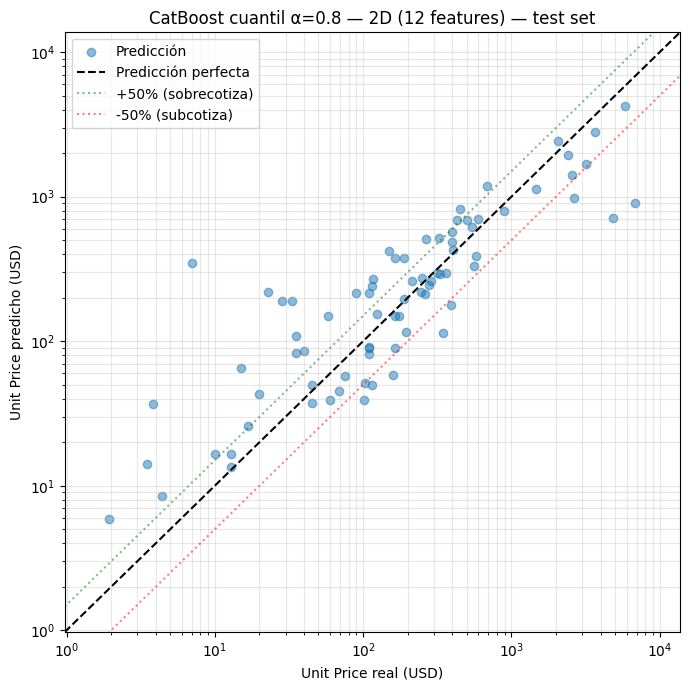

In [12]:
# Visualización: predicción vs real en USD (escala log)
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.scatter(np.exp(y_test), np.exp(test_pred), alpha=0.5, label='Predicción')
lim = [np.exp(y_test).min() * 0.5, np.exp(y_test).max() * 2]
ax.plot(lim, lim, 'k--', label='Predicción perfecta')
ax.plot(lim, [v * 1.5 for v in lim], 'g:', alpha=0.5, label='+50% (sobrecotiza)')
ax.plot(lim, [v * 0.5 for v in lim], 'r:', alpha=0.5, label='-50% (subcotiza)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Unit Price real (USD)')
ax.set_ylabel('Unit Price predicho (USD)')
ax.set_title(f'CatBoost cuantil α={ALPHA} — 2D (12 features) — test set')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Diagnóstico: top-10 peores predicciones en test
test_results = X_test.copy()
test_results['actual_usd']    = np.exp(y_test.values)
test_results['predicted_usd'] = np.exp(test_pred)
test_results['error_pct']     = (test_results['predicted_usd'] - test_results['actual_usd']) / test_results['actual_usd'] * 100
test_results['abs_error_pct'] = test_results['error_pct'].abs()

print('=== Top 10 peores predicciones (mayor error absoluto en %) ===\n')
worst_cols = ['actual_usd', 'predicted_usd', 'error_pct', 'Quantity', 'Material', 'Technology', 'Tolerance', 'stock_dimensions_mm.x', 'stock_dimensions_mm.y', 'stock_dimensions_mm.z']
worst = test_results.sort_values('abs_error_pct', ascending=False).head(10)[worst_cols]
print(worst.to_string())

print('\n=== Top 5 peores subestimaciones (perdemos dinero) ===\n')
under = test_results[test_results['error_pct'] < 0].sort_values('error_pct').head(5)[worst_cols]
print(under.to_string())

print('\n=== Top 5 peores sobreestimaciones (perdemos deal) ===\n')
over = test_results[test_results['error_pct'] > 0].sort_values('error_pct', ascending=False).head(5)[worst_cols]
print(over.to_string())

=== Top 10 peores predicciones (mayor error absoluto en %) ===

     actual_usd  predicted_usd    error_pct  Quantity       Material     Technology  Tolerance  stock_dimensions_mm.x  stock_dimensions_mm.y  stock_dimensions_mm.z
364    7.006023     349.760675  4892.285841        11    4140T Steel  CNC Multiaxis      0.050                   95.2                  133.3                  133.3
366    3.800000      36.589956   862.893583        30     Other_rare  CNC Multiaxis      0.076                   25.4                   25.4                   25.4
277   23.002400     220.010703   856.468470        20          Other  CNC Multiaxis      0.020                  120.6                   19.0                  120.6
244   28.177940     191.185358   578.493028         1          Other  CNC Multiaxis      0.010                   38.1                   95.2                   19.0
243   33.065950     191.185358   478.194058         1          Other  CNC Multiaxis      0.010                   38.

## 8. Feature importance

                  feature  importance
0                Quantity   21.381420
1   stock_dimensions_mm.z   13.556562
2               Finishing    8.694634
3   stock_dimensions_mm.x    7.730917
4   stock_dimensions_mm.y    7.633414
5                Material    7.515826
6              Technology    6.404018
7         Post Production    6.279477
8          Heat Treatment    5.911457
9               part_type    5.516972
10              Tolerance    5.433488
11            total_holes    3.941815


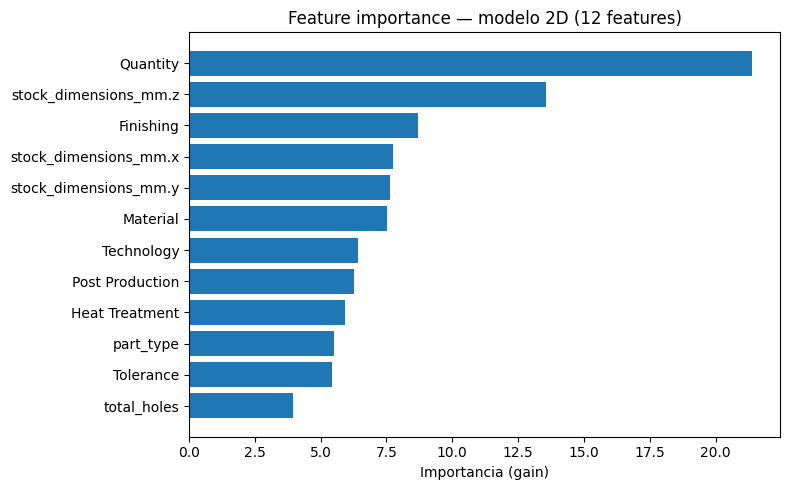

In [14]:
feature_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.get_feature_importance(),
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(feature_imp.to_string())

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.barh(feature_imp['feature'][::-1], feature_imp['importance'][::-1])
ax.set_xlabel('Importancia (gain)')
ax.set_title('Feature importance — modelo 2D (12 features)')
plt.tight_layout()
plt.show()

## 9. SHAP

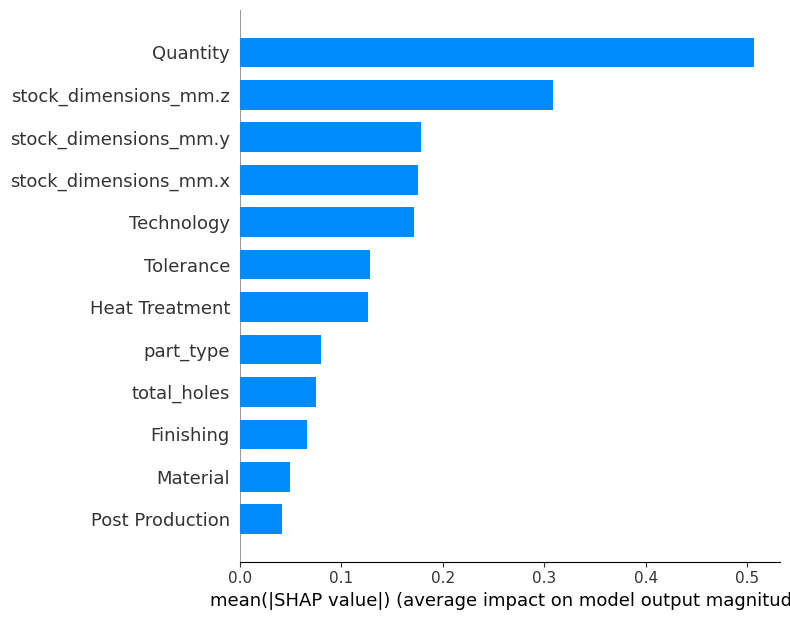

In [15]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(Pool(X_test, cat_features=cat_features))

shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

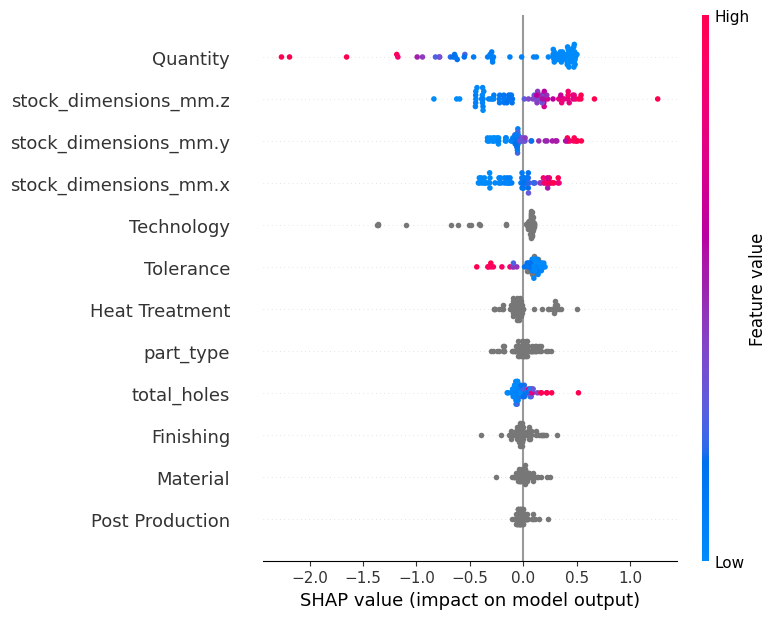

In [16]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

## 10. Comparativa v1 (CAD, 22 features) vs v2 (2D, 12 features)

Los valores **v1** vienen de `02_modeling.ipynb` con la última config (CatBoost cuantil α=0.8, regularización agresiva). Mismo SEED, mismo split, misma config — la única diferencia son las 10 features eliminadas (8 CAD-only + `stock_volume_cm3` + `log_quantity`).

**Cómo leer el resultado**:
- Si v2 está dentro del **±10% de v1** en métricas clave (P50, MAE log, subestimación), la decisión de ir 2D-only es ganadora porque el costo en accuracy es chico vs el potencial de **multiplicar el dataset**.
- Si v2 está significativamente peor (>25% caída), hay que reconsiderar qué features son realmente CAD-only o buscar proxies humanos.

In [17]:
# Métricas v1 hardcoded del último run de 02_modeling.ipynb
# (Si re-corres el 02 cambiarán ligeramente — actualiza estos valores manualmente)
v1_metrics = {
    'mae_log': 0.6391,
    'rmse_log': 0.9218,
    'mape_usd': 176.2,
    'p50_mape': 43.3,
    'p90_mape': 197.4,
    'p99_mape': 2168.5,
    'underpred_pct': 52.6,
}

# Tabla comparativa
rows = []
for key in ['mae_log', 'rmse_log', 'mape_usd', 'p50_mape', 'p90_mape', 'p99_mape', 'underpred_pct']:
    v1 = v1_metrics[key]
    v2 = v2_metrics[key]
    delta = v2 - v1
    delta_pct = (delta / abs(v1)) * 100 if v1 != 0 else 0
    rows.append({
        'metric': key,
        'v1 (CAD, 22 feat)': f'{v1:.3f}',
        'v2 (2D, 12 feat)':  f'{v2:.3f}',
        'delta': f'{delta:+.3f}',
        'delta %': f'{delta_pct:+.1f}%',
    })

comp = pd.DataFrame(rows)
print('=== Comparativa v1 (con CAD) vs v2 (sólo 2D) ===\n')
print(comp.to_string(index=False))

# Veredicto rápido
p50_change = ((v2_metrics['p50_mape'] - v1_metrics['p50_mape']) / v1_metrics['p50_mape']) * 100
mae_change = ((v2_metrics['mae_log']  - v1_metrics['mae_log'])  / v1_metrics['mae_log'])  * 100

print('\n=== Veredicto ===')
print(f'P50 MAPE:    {v1_metrics["p50_mape"]:.1f}% -> {v2_metrics["p50_mape"]:.1f}%  ({p50_change:+.1f}%)')
print(f'MAE log:     {v1_metrics["mae_log"]:.4f} -> {v2_metrics["mae_log"]:.4f}  ({mae_change:+.1f}%)')
print()
if abs(p50_change) <= 15 and abs(mae_change) <= 15:
    print('  ✓ Caída pequeña — la decisión 2D es VIABLE.')
    print('    Procede ampliar el dataset llenando manualmente los pedidos sin CAD.')
elif abs(p50_change) <= 30:
    print('  ~ Caída moderada — decisión 2D es ACEPTABLE pero con costos.')
    print('    Validar con negocio si la accuracy actual del v1 es realmente accionable.')
else:
    print('  ✗ Caída grande — perder esas features cuesta mucho accuracy.')
    print('    Considerar mantener CAD pipeline o agregar proxies humanos para las features perdidas.')

=== Comparativa v1 (con CAD) vs v2 (sólo 2D) ===

       metric v1 (CAD, 22 feat) v2 (2D, 12 feat)    delta delta %
      mae_log             0.639            0.650   +0.011   +1.7%
     rmse_log             0.922            0.919   -0.003   -0.3%
     mape_usd           176.200          156.191  -20.009  -11.4%
     p50_mape            43.300           45.130   +1.830   +4.2%
     p90_mape           197.400          205.581   +8.181   +4.1%
     p99_mape          2168.500         1789.654 -378.846  -17.5%
underpred_pct            52.600           46.154   -6.446  -12.3%

=== Veredicto ===
P50 MAPE:    43.3% -> 45.1%  (+4.2%)
MAE log:     0.6391 -> 0.6503  (+1.7%)

  ✓ Caída pequeña — la decisión 2D es VIABLE.
    Procede ampliar el dataset llenando manualmente los pedidos sin CAD.


## 11. Persistencia

In [18]:
final_model.save_model(str(MODEL_PATH))

schema = {
    'feature_order': list(X_train.columns),
    'cat_features': cat_features,
    'cat_categories': {c: sorted(X_train[c].unique().tolist()) for c in cat_features},
    'target_log': TARGET,
    'target_usd': TARGET_USD,
    'alpha': ALPHA,
    'random_seed': SEED,
    'tree_count': final_model.tree_count_,
    'variant': '2d_human_input',
    'n_features': len(X_train.columns),
}

with open(SCHEMA_PATH, 'w', encoding='utf-8') as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)

print(f'Modelo guardado: {MODEL_PATH}')
print(f'Schema guardado: {SCHEMA_PATH}')

Modelo guardado: catboost_model_2d.cbm
Schema guardado: catboost_schema_2d.json


## Próximo paso

Si la **comparativa v1 vs v2** (sección 10) muestra una caída aceptable:

1. **Diseñar el form humano** con los 12 campos identificados.
2. **Backfill** de pedidos históricos con sólo plano 2D — cada uno suma una fila al dataset.
3. **Reentrenar** con el dataset ampliado: probablemente la nueva v2 ampliada supere a la v1 actual con CAD, porque más datos > más features cuando el dataset es chico.

Si la caída es grande (>30%):
- Investigar si hay **proxies humanos** para las features perdidas (ej. "complejidad estimada" como reemplazo de `complex_ratio`/`faces_qty`/etc.).
- O bien aceptar que el modelo CAD es necesario y enfocar el esfuerzo en hacer más rápido el análisis de CAD.